# 🏦 Bank Loan Analysis using Python



## Project Objective

The objective of this project is to analyze a bank loan dataset using Python to understand customer demographics, loan patterns, and financial relationships. The analysis helps identify trends that can support better lending decisions.

#Import Libraries

In [39]:
import pandas as pd
import matplotlib.pyplot as plt

## Load Dataset

In [40]:
import pandas as pd
df =pd.read_csv("Bank dataset 2.csv")
df.head()

,customer_id,age,gender,marital_status,education_level,annual_income,loan_amount,credit_score,employment_years,employment_type,...,category_feature_173,flag_feature_174,flag_feature_175,numeric_feature_176,category_feature_177,ratio_feature_178,category_feature_179,flag_feature_180,flag_feature_181,ratio_feature_182
0,309271753,NaN,Female,Single,High School,22055.04,108494.96,610.0,1.7,NaN,...,C,0.0,NaN,270.03,C,0.1387,B,1.0,0.0,0.9670
1,311621071,47.0,Male,Single,PhD,17331.80,452629.07,682.0,25.1,Part-time,...,B,0.0,0.0,NaN,C,0.4020,D,0.0,0.0,0.4851
2,267974712,32.0,Male,Single,High School,50765.35,NaN,568.0,9.2,Full-time,...,A,0.0,0.0,1267.85,B,0.4022,D,0.0,0.0,0.3559
3,872416260,66.0,Male,NaN,Bachelor,29430.52,314325.91,600.0,37.2,Full-time,...,C,0.0,0.0,874.84,B,0.8048,C,0.0,NaN,0.0481
4,255253104,25.0,Male,Single,Master,9079.24,353758.27,578.0,16.9,Part-time,...,C,0.0,0.0,NaN,A,0.7655,D,0.0,0.0,0.1408


## Data Understanding

### Key Observations

- Dataset contains *50,000 rows* and *200 columns*.
- The dataset includes customer demographics, loan details, employment information, and financial attributes.
- Missing values are present in several columns and need to be handled before analysis

In [41]:
df.shape

(50000, 200)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 200 entries, customer_id to ratio_feature_182
dtypes: float64(136), int64(1), str(63)
memory usage: 76.3 MB


In [43]:
df.describe()

,customer_id,age,annual_income,loan_amount,credit_score,employment_years,debt_to_income_ratio,existing_loans,loan_term_months,interest_rate,...,ratio_feature_169,numeric_feature_170,ratio_feature_171,flag_feature_174,flag_feature_175,numeric_feature_176,ratio_feature_178,flag_feature_180,flag_feature_181,ratio_feature_182
count,5.000000e+04,46017.000000,46047.000000,45906.000000,45991.000000,45985.000000,46085.000000,46002.000000,46009.000000,46051.000000,...,46034.000000,45932.000000,46031.000000,46068.000000,46030.000000,45989.000000,46002.000000,46012.000000,45986.000000,46022.000000
mean,5.482217e+08,46.049764,39284.045827,250933.609793,678.938640,19.928551,0.431932,1.399374,119.065487,13.732382,...,0.501631,1000.628205,0.499955,0.301902,0.303997,1000.350504,0.503203,0.299270,0.298743,0.501741
std,2.594400e+08,16.459370,25681.066507,142942.792628,83.510198,11.546443,0.242177,1.181224,111.440756,6.505040,...,0.287814,299.483238,0.289205,0.459088,0.459986,299.312586,0.289245,0.457943,0.457712,0.289626
min,1.000450e+08,18.000000,2368.100000,1003.770000,306.000000,0.000000,0.010000,0.000000,12.000000,2.500000,...,0.000000,-287.220000,0.000000,0.000000,0.000000,-244.510000,0.000000,0.000000,0.000000,0.000000
25%,3.233766e+08,32.000000,22027.535000,128115.680000,623.000000,9.900000,0.222000,1.000000,36.000000,8.120000,...,0.253800,798.277500,0.248300,0.000000,0.000000,797.670000,0.253100,0.000000,0.000000,0.250800
50%,5.471212e+08,46.000000,32917.530000,251534.340000,680.000000,19.900000,0.434000,1.000000,60.000000,13.700000,...,0.502500,1001.060000,0.499800,0.000000,0.000000,997.080000,0.505000,0.000000,0.000000,0.504000
75%,7.705615e+08,60.000000,49034.900000,373636.952500,737.000000,29.900000,0.642000,2.000000,180.000000,19.370000,...,0.748700,1202.522500,0.750650,1.000000,1.000000,1204.210000,0.753300,1.000000,1.000000,0.752700
max,9.999976e+08,74.000000,428919.290000,499978.690000,850.000000,40.000000,0.850000,7.000000,360.000000,25.000000,...,1.000000,2221.790000,1.000000,1.000000,1.000000,2358.250000,1.000000,1.000000,1.000000,1.000000


In [44]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Columns: 200 entries, customer_id to ratio_feature_182
dtypes: float64(136), int64(1), str(63)
memory usage: 76.3 MB


In [45]:
df.isnull().sum()

customer_id                0
age                     3983
gender                  4015
marital_status          4136
education_level         4001
                        ... 
ratio_feature_178       3998
category_feature_179    3794
flag_feature_180        3988
flag_feature_181        4014
ratio_feature_182       3978
Length: 200, dtype: int64

In [46]:
df.duplicated().sum()

np.int64(0)

In [47]:
missing_percentage=(df.isnull().sum()/len(df))*100
missing_percentage.sort_values(ascending=False)

flag_feature_127        8.328
flag_feature_135        8.286
category_feature_112    8.284
marital_status          8.272
ratio_feature_99        8.252
                        ...  
ratio_feature_132       7.752
category_feature_72     7.718
ratio_feature_5         7.682
category_feature_179    7.588
customer_id             0.000
Length: 200, dtype: float64

## Data Cleaning

### Steps Performed

- Selected the relevant columns required for analysis.
- Removed unnecessary columns from the dataset.
- Filled missing values in numerical columns using the median.
- Filled missing values in categorical columns using the mode.
- Verified that no missing values remained after cleaning.

In [48]:
important_columns = [
    "customer_id",
    "age",
    "gender",
    "marital_status",
    "education_level",
    "annual_income",
    "loan_amount",
    "credit_score",
    "employment_years",
    "employment_type",
    "loan_purpose",
    "home_ownership",
    "debt_to_income_ratio",
    "existing_loans",
    "loan_term_months",
    "interest_rate",
    "loan_status",
    "application_date"
]

df_clean = df[important_columns]

df_clean.head()

,customer_id,age,gender,marital_status,education_level,annual_income,loan_amount,credit_score,employment_years,employment_type,loan_purpose,home_ownership,debt_to_income_ratio,existing_loans,loan_term_months,interest_rate,loan_status,application_date
0,309271753,NaN,Female,Single,High School,22055.04,108494.96,610.0,1.7,NaN,Personal,Own,0.362,NaN,120.0,18.29,Rejected,2018-08-20
1,311621071,47.0,Male,Single,PhD,17331.80,452629.07,682.0,25.1,Part-time,Business,Mortgage,0.129,2.0,24.0,9.28,Rejected,2019-11-06
2,267974712,32.0,Male,Single,High School,50765.35,NaN,568.0,9.2,Full-time,Education,Own,0.452,1.0,24.0,7.67,Approved,2015-08-02
3,872416260,66.0,Male,NaN,Bachelor,29430.52,314325.91,600.0,37.2,Full-time,Car,Own,0.659,0.0,180.0,5.00,Approved,2023-02-14
4,255253104,25.0,Male,Single,Master,9079.24,353758.27,578.0,16.9,Part-time,Personal,Rent,0.405,0.0,60.0,22.69,Approved,2020-06-07


In [49]:
df_clean.isnull().sum()

customer_id                0
age                     3983
gender                  4015
marital_status          4136
education_level         4001
annual_income           3953
loan_amount             4094
credit_score            4009
employment_years        4015
employment_type         3938
loan_purpose            4007
home_ownership          3992
debt_to_income_ratio    3915
existing_loans          3998
loan_term_months        3991
interest_rate           3949
loan_status             4039
application_date        3987
dtype: int64

In [50]:
# Fill numeric columns with median

numeric_columns = [
    "age",
    "annual_income",
    "loan_amount",
    "credit_score",
    "employment_years",
    "debt_to_income_ratio",
    "existing_loans",
    "loan_term_months",
    "interest_rate"
]

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [51]:
categorical_columns = [
    "gender",
    "marital_status",
    "education_level",
    "employment_type",
    "loan_purpose",
    "home_ownership",
    "loan_status"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [52]:
df_clean.isnull().sum()

customer_id                0
age                        0
gender                     0
marital_status             0
education_level            0
annual_income              0
loan_amount                0
credit_score               0
employment_years           0
employment_type            0
loan_purpose               0
home_ownership             0
debt_to_income_ratio       0
existing_loans             0
loan_term_months           0
interest_rate              0
loan_status                0
application_date        3987
dtype: int64

In [53]:
df_clean = df_clean.drop(columns=["application_date"])

In [54]:
df_clean.isnull().sum()

customer_id             0
age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
loan_amount             0
credit_score            0
employment_years        0
employment_type         0
loan_purpose            0
home_ownership          0
debt_to_income_ratio    0
existing_loans          0
loan_term_months        0
interest_rate           0
loan_status             0
dtype: int64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, identify patterns, and extract meaningful business insights from the cleaned dataset.

## 1. Loan Amount Distribution

### Purpose
To understand how loan amounts are distributed among customers.

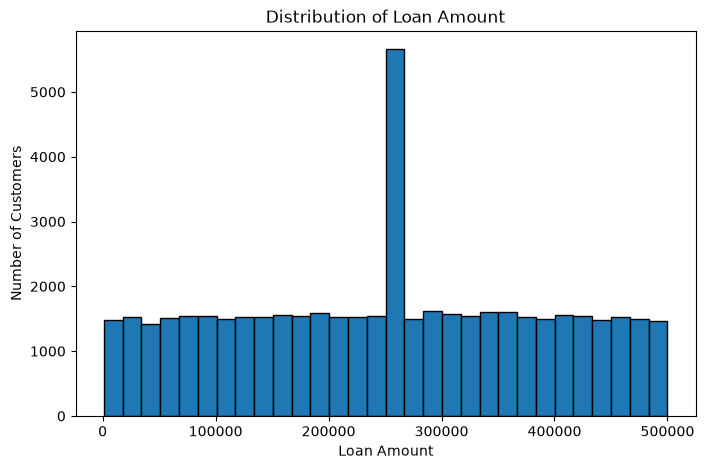

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(df_clean["loan_amount"], bins=30, edgecolor="black")

plt.title("Distribution of Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Number of Customers")
plt.savefig("images/loan_amount_distribution.png")
plt.show()

### Observation

The loan amount distribution is spread across different values, but there is a noticeable spike around ₹251,534. This spike occurred because missing loan amounts were replaced with the median value during data cleaning.

### Business Insight

The dataset contains customers requesting different loan amounts. The noticeable spike is a result of data preprocessing and should be considered while interpreting the distribution.

In [56]:
df_clean["loan_amount"].value_counts().head(10)

loan_amount
251534.34    4094
233277.68       2
102583.38       2
246259.91       2
366887.32       2
21678.78        2
102890.18       2
446155.51       2
105693.83       2
436468.74       2
Name: count, dtype: int64

## 2. Gender Distribution

### Purpose

To analyze the distribution of loan applicants based on gender.

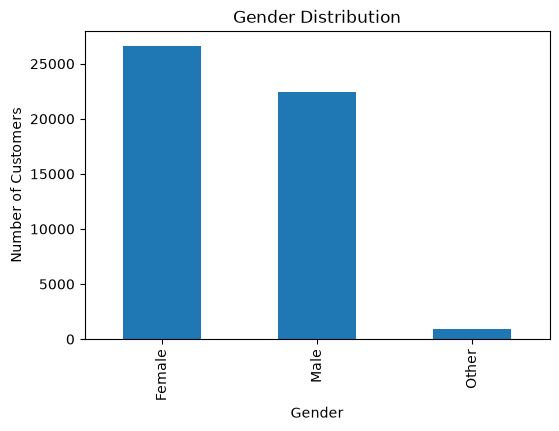

In [57]:
plt.figure(figsize=(6,4))

df_clean["gender"].value_counts().plot(kind="bar")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.savefig("images/gender_distribution.png")
plt.show()

### Observation

The gender distribution shows that female applicants make up the largest share of loan applicants, followed by male applicants, while applicants in the "Other" category represent only a very small portion of the dataset.

### Business Insight

The bank receives a higher number of loan applications from female customers in this dataset. This information can help the bank understand its customer base and design targeted products or marketing campaigns.

## 3. Loan Purpose Distribution

### Purpose

To understand the reasons customers apply for loans

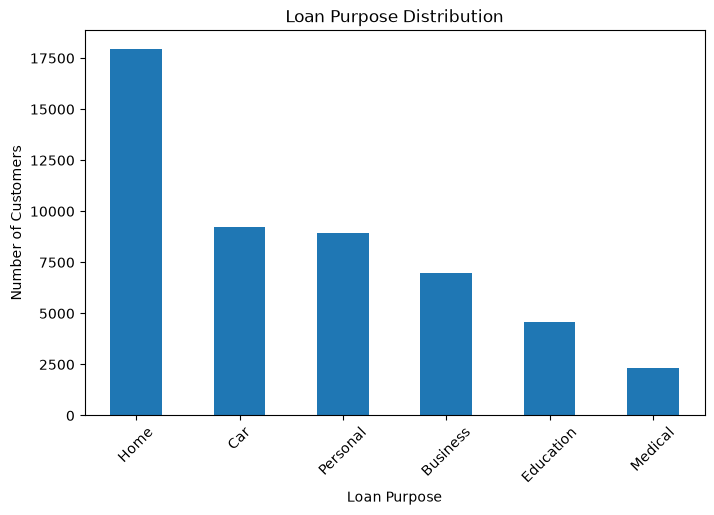

In [58]:
plt.figure(figsize=(8,5))

df_clean["loan_purpose"].value_counts().plot(kind="bar")

plt.title("Loan Purpose Distribution")
plt.xlabel("Loan Purpose")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)
plt.savefig("images/loan_purpose_distribution.png")
plt.show()



### Observation

The loan purpose distribution shows that home loans are the most common type of loan application, while medical loans have the fewest applicants.

### Business Insight

The high demand for home loans indicates that housing finance is the primary borrowing need among customers. The bank can prioritize home loan products while further analyzing the lower demand for medical loans.

## 4. Credit Score Distribution

### Purpose

To analyze the distribution of customers based on their credit scores.

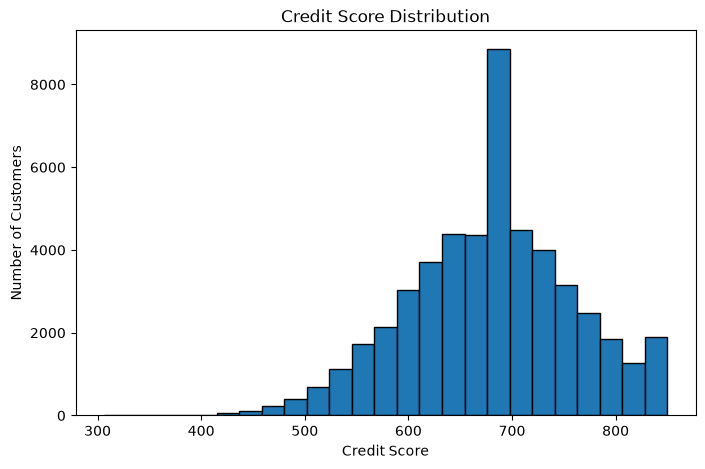

In [59]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["credit_score"], bins=25, edgecolor="black")

plt.title("Credit Score Distribution")
plt.xlabel("Credit Score")
plt.ylabel("Number of Customers")
plt.savefig("images/credit_score_distribution.png")
plt.show()

### Observation

Most customers have credit scores around 700, while only a small number of customers have credit scores below 400.

### Business Insight

The majority of applicants have moderate to good creditworthiness, indicating a relatively low-risk customer base. Applicants with very low credit scores may require stricter loan evaluation.

## 5. Annual Income vs Loan Amount

### Purpose

To analyze the relationship between annual income and loan amount.

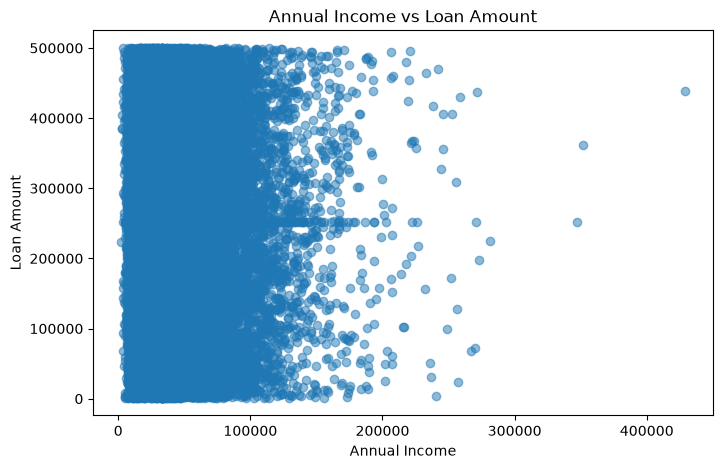

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df_clean["annual_income"],
            df_clean["loan_amount"],
            alpha=0.5)

plt.title("Annual Income vs Loan Amount")
plt.xlabel("Annual Income")
plt.ylabel("Loan Amount")
plt.savefig("images/income_vs_loan_amount.png")
plt.show()



### Observation

The scatter plot shows that customers with similar annual incomes have taken different loan amounts. The data points are widely scattered, indicating no strong relationship between annual income and loan amount.

### Business Insight

Annual income alone is not sufficient to determine the loan amount requested by customers. The bank should also consider other factors such as credit score, employment history, and debt-to-income ratio.

## 6. Correlation Heatmap

### Purpose

To examine the relationships between numerical variables in the dataset.

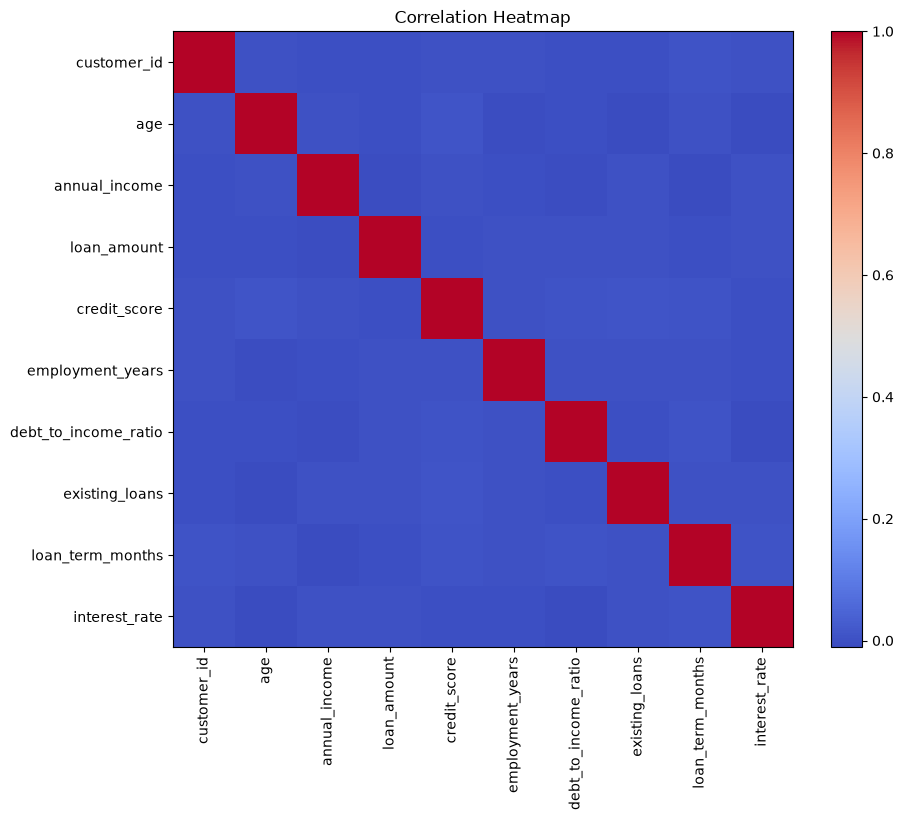

In [61]:
import matplotlib.pyplot as plt

correlation = df_clean.select_dtypes(include="number").corr()

plt.figure(figsize=(10,8))

plt.imshow(correlation, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
plt.yticks(range(len(correlation.columns)), correlation.columns)

plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png")
plt.show()

### Observation

The correlation heatmap shows that most numerical variables have weak correlations with each other, while the diagonal represents a perfect correlation of each variable with itself.

### Business Insight

No single numerical variable strongly predicts another. Therefore, loan approval decisions should be based on multiple factors rather than relying on a single metric.

# Conclusion

This project analyzed a bank loan dataset using Python, Pandas, and Matplotlib. After cleaning the data and performing exploratory data analysis, key patterns related to loan amounts, customer demographics, credit scores, and loan purposes were identified. The analysis showed that loan decisions should consider multiple factors rather than relying on a single variable. Overall, the project demonstrates how data analysis can support informed decision-making in the banking sector.